# Random Forest

### Imports

In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub as kh
import os

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    auc
)
from sklearn.inspection import permutation_importance

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

In [2]:
path = kh.dataset_download("rabieelkharoua/alzheimers-disease-dataset")
print("Path to dataset files:", path)

files = os.listdir(path)
print("Files in directory:", files)

csv_file = [f for f in files if f.endswith('.csv')][0]
csv_path = os.path.join(path, csv_file)


df = pd.read_csv(csv_path)
print("Shape:", df.shape)
df.head()

Path to dataset files: C:\Users\jonas\.cache\kagglehub\datasets\rabieelkharoua\alzheimers-disease-dataset\versions\1
Files in directory: ['alzheimers_disease_data.csv']
Shape: (2149, 35)


,PatientID,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,SleepQuality,FamilyHistoryAlzheimers,CardiovascularDisease,Diabetes,Depression,HeadInjury,Hypertension,SystolicBP,DiastolicBP,CholesterolTotal,CholesterolLDL,CholesterolHDL,CholesterolTriglycerides,MMSE,FunctionalAssessment,MemoryComplaints,BehavioralProblems,ADL,Confusion,Disorientation,PersonalityChanges,DifficultyCompletingTasks,Forgetfulness,Diagnosis,DoctorInCharge
0,4751,73,0,0,2,22.927749,0,13.297218,6.327112,1.347214,9.025679,0,0,1,1,0,0,142,72,242.366840,56.150897,33.682563,162.189143,21.463532,6.518877,0,0,1.725883,0,0,0,1,0,0,XXXConfid
1,4752,89,0,0,0,26.827681,0,4.542524,7.619885,0.518767,7.151293,0,0,0,0,0,0,115,64,231.162595,193.407996,79.028477,294.630909,20.613267,7.118696,0,0,2.592424,0,0,0,0,1,0,XXXConfid
2,4753,73,0,3,1,17.795882,0,19.555085,7.844988,1.826335,9.673574,1,0,0,0,0,0,99,116,284.181858,153.322762,69.772292,83.638324,7.356249,5.895077,0,0,7.119548,0,1,0,1,0,0,XXXConfid
3,4754,74,1,0,1,33.800817,1,12.209266,8.428001,7.435604,8.392554,0,0,0,0,0,0,118,115,159.582240,65.366637,68.457491,277.577358,13.991127,8.965106,0,1,6.481226,0,0,0,0,0,0,XXXConfid
4,4755,89,0,0,0,20.716974,0,18.454356,6.310461,0.795498,5.597238,0,0,0,0,0,0,94,117,237.602184,92.869700,56.874305,291.198780,13.517609,6.045039,0,0,0.014691,0,0,1,1,0,0,XXXConfid


## 3. Basic structure and missing values

In [3]:
print(df.info())
print("\nMissing values by column:")
display(df.isna().sum().sort_values(ascending=False).to_frame("missing_count"))

<class 'pandas.DataFrame'>
RangeIndex: 2149 entries, 0 to 2148
Data columns (total 35 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   PatientID                  2149 non-null   int64  
 1   Age                        2149 non-null   int64  
 2   Gender                     2149 non-null   int64  
 3   Ethnicity                  2149 non-null   int64  
 4   EducationLevel             2149 non-null   int64  
 5   BMI                        2149 non-null   float64
 6   Smoking                    2149 non-null   int64  
 7   AlcoholConsumption         2149 non-null   float64
 8   PhysicalActivity           2149 non-null   float64
 9   DietQuality                2149 non-null   float64
 10  SleepQuality               2149 non-null   float64
 11  FamilyHistoryAlzheimers    2149 non-null   int64  
 12  CardiovascularDisease      2149 non-null   int64  
 13  Diabetes                   2149 non-null   int64  
 14  Dep

,missing_count
PatientID,0
Age,0
Gender,0
Ethnicity,0
EducationLevel,0
BMI,0
Smoking,0
AlcoholConsumption,0
PhysicalActivity,0
DietQuality,0


In [ ]:
# Drop non-predictive identifiers if present
drop_if_present = ["PatientID", "DoctorInCharge"]
df = df.drop(columns=[c for c in drop_if_present if c in df.columns])

print("Columns after dropping ID-like columns:")
print(df.columns.tolist())

Columns after dropping ID-like columns:
['Age', 'Gender', 'Ethnicity', 'EducationLevel', 'BMI', 'Smoking', 'AlcoholConsumption', 'PhysicalActivity', 'DietQuality', 'SleepQuality', 'FamilyHistoryAlzheimers', 'CardiovascularDisease', 'Diabetes', 'Depression', 'HeadInjury', 'Hypertension', 'SystolicBP', 'DiastolicBP', 'CholesterolTotal', 'CholesterolLDL', 'CholesterolHDL', 'CholesterolTriglycerides', 'MMSE', 'FunctionalAssessment', 'MemoryComplaints', 'BehavioralProblems', 'ADL', 'Confusion', 'Disorientation', 'PersonalityChanges', 'DifficultyCompletingTasks', 'Forgetfulness', 'Diagnosis']


## 4. Target distribution

Diagnosis
0    1389
1     760
Name: count, dtype: int64

Class proportions:
Diagnosis
0    0.646
1    0.354
Name: proportion, dtype: float64


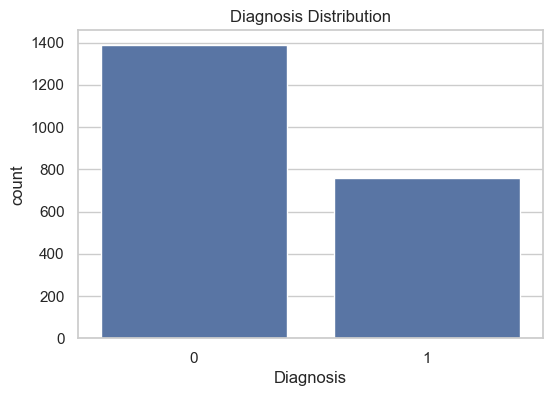

In [5]:
target_col = "Diagnosis"

print(df[target_col].value_counts(dropna=False))
print("\nClass proportions:")
print(df[target_col].value_counts(normalize=True).round(3))

plt.figure(figsize=(6,4))
sns.countplot(data=df, x=target_col)
plt.title("Diagnosis Distribution")
plt.show()

## 5. Split columns by type

In [6]:
categorical_cols = df.select_dtypes(include=["object", "category", "bool"]).columns.tolist()
numeric_cols = [c for c in df.columns if c not in categorical_cols + [target_col]]

print("Categorical columns:", categorical_cols)
print("Numeric columns:", numeric_cols)

Categorical columns: []
Numeric columns: ['Age', 'Gender', 'Ethnicity', 'EducationLevel', 'BMI', 'Smoking', 'AlcoholConsumption', 'PhysicalActivity', 'DietQuality', 'SleepQuality', 'FamilyHistoryAlzheimers', 'CardiovascularDisease', 'Diabetes', 'Depression', 'HeadInjury', 'Hypertension', 'SystolicBP', 'DiastolicBP', 'CholesterolTotal', 'CholesterolLDL', 'CholesterolHDL', 'CholesterolTriglycerides', 'MMSE', 'FunctionalAssessment', 'MemoryComplaints', 'BehavioralProblems', 'ADL', 'Confusion', 'Disorientation', 'PersonalityChanges', 'DifficultyCompletingTasks', 'Forgetfulness']


## 6. Univariate visual analysis

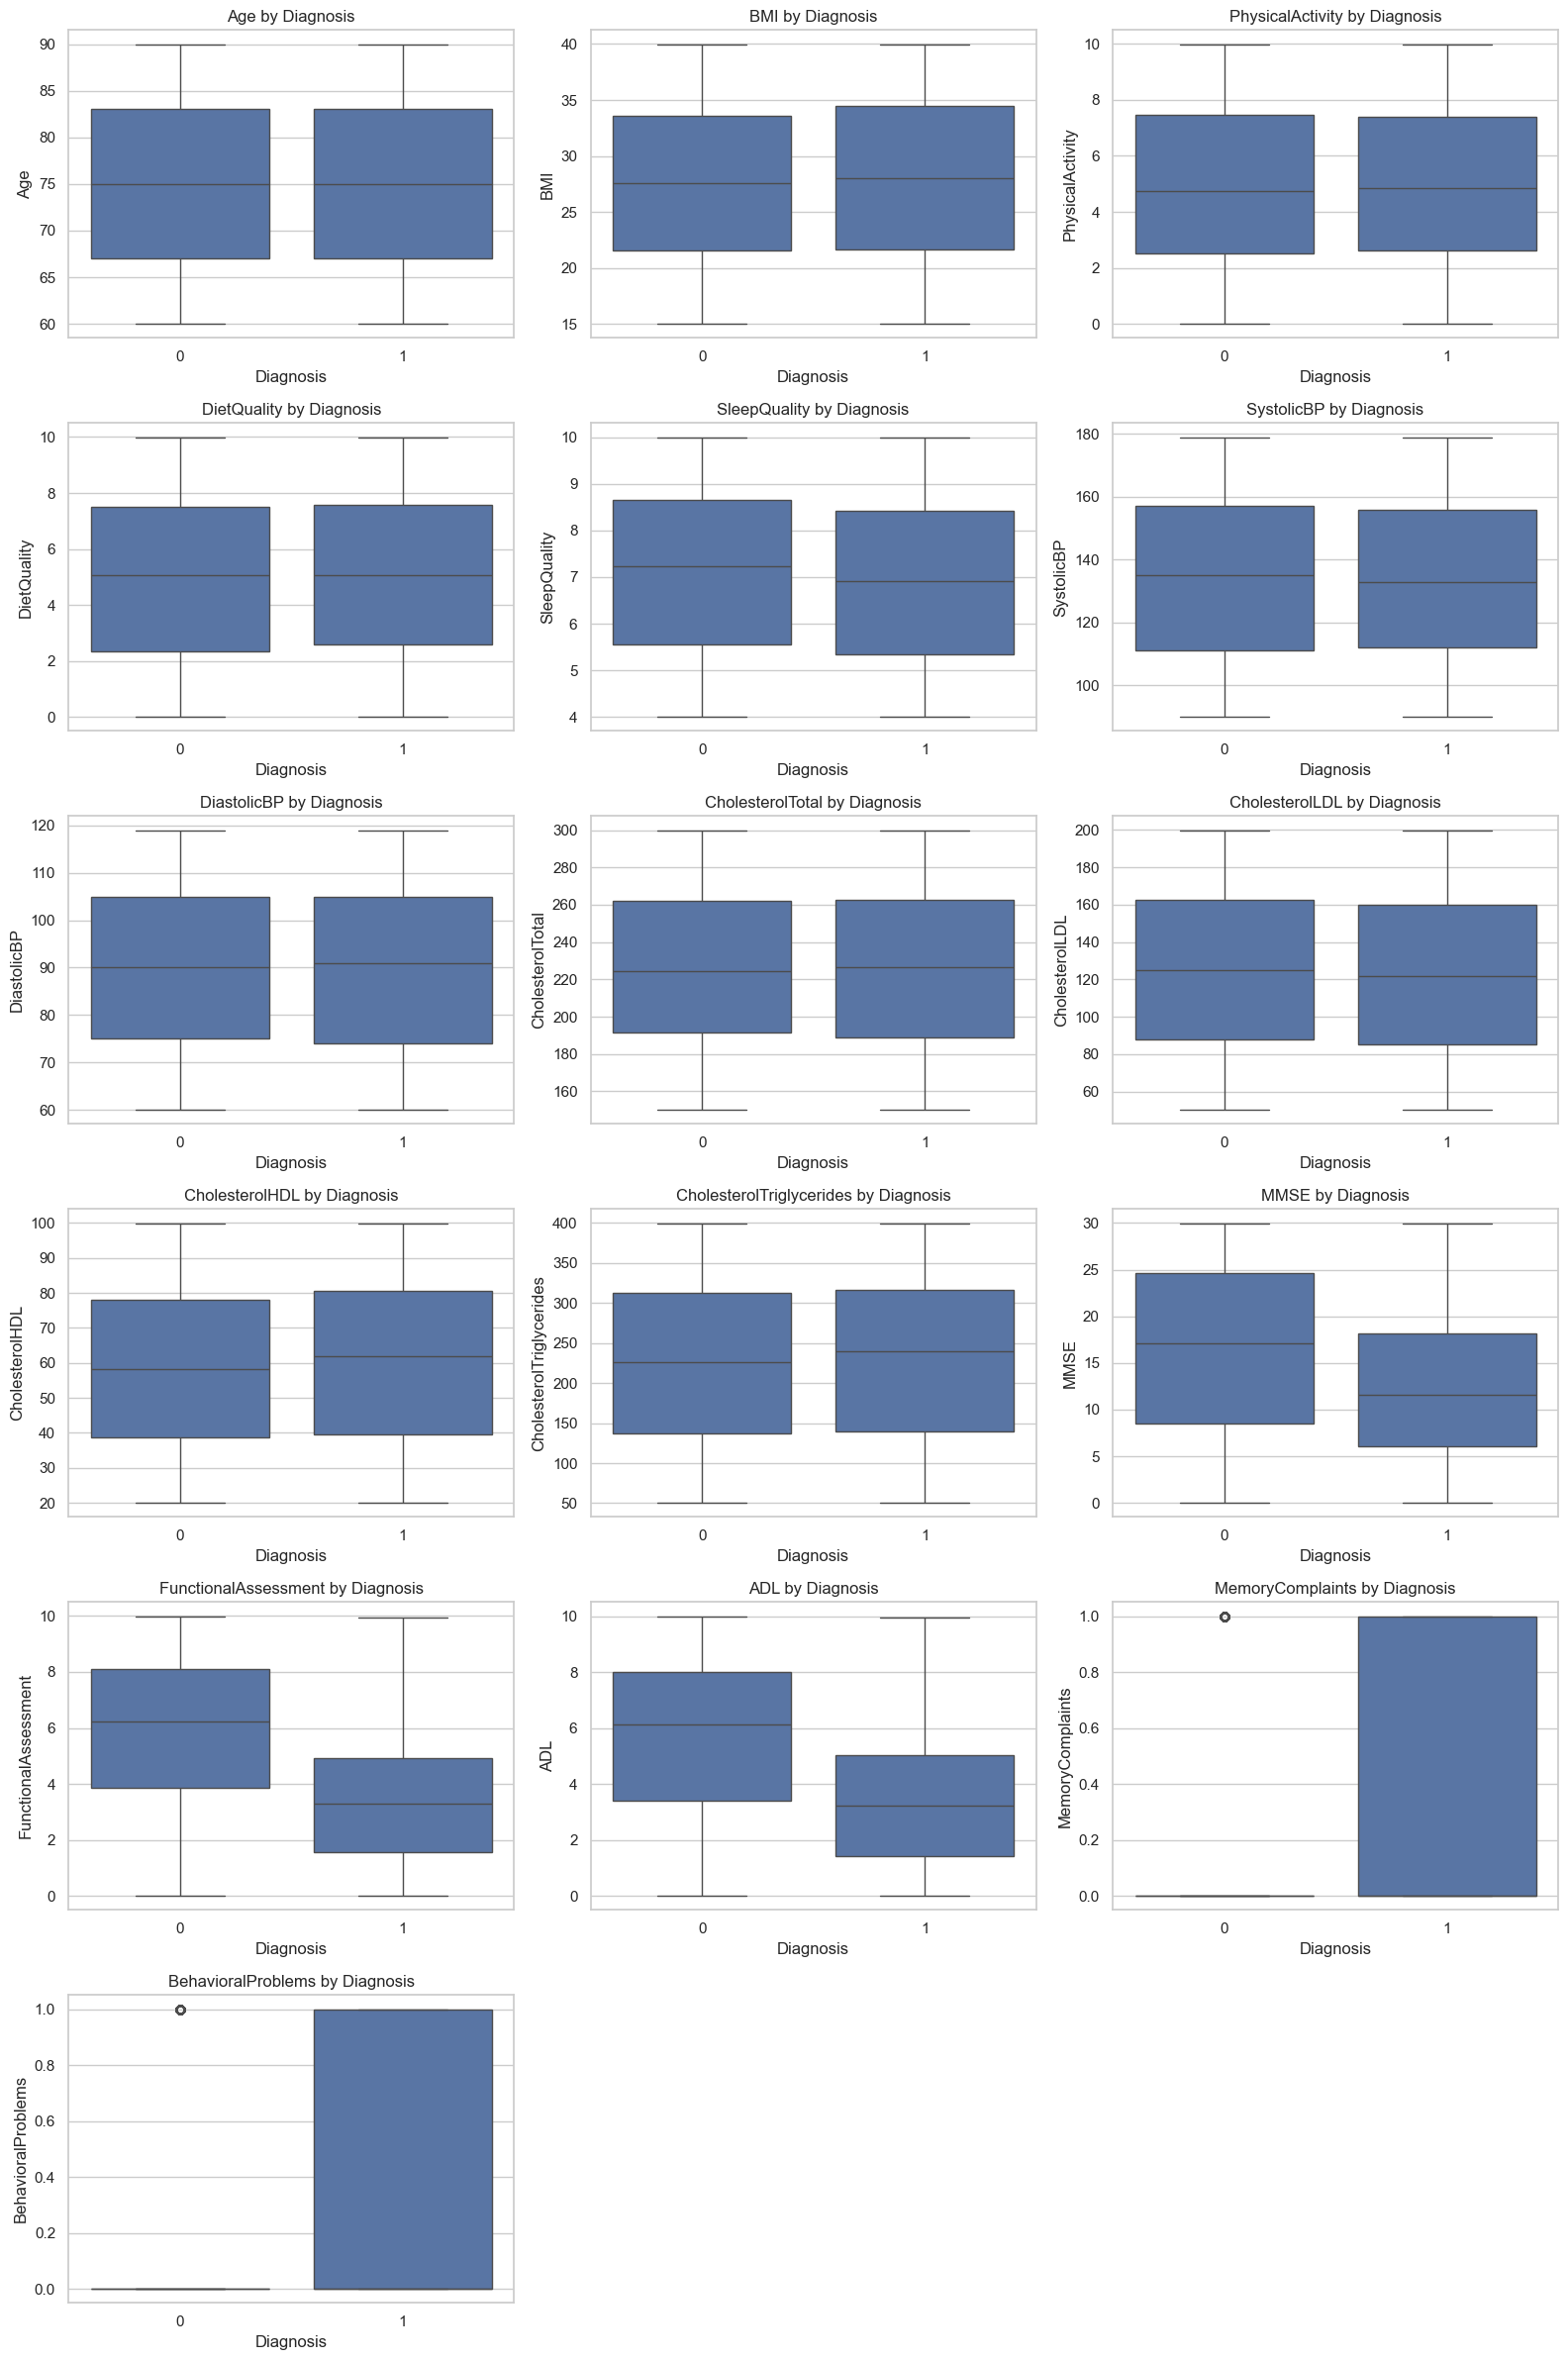

In [8]:
features_to_plot = [
    c for c in [
        "Age", "BMI", "PhysicalActivity", "DietQuality", "SleepQuality",
        "SystolicBP", "DiastolicBP", "CholesterolTotal", "CholesterolLDL",
        "CholesterolHDL", "CholesterolTriglycerides",
        "MMSE", "FunctionalAssessment", "ADL", "MemoryComplaints",
        "BehavioralProblems"
    ] if c in df.columns
]

n_cols = 3
n_rows = int(np.ceil(len(features_to_plot) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4*n_rows))
axes = np.array(axes).reshape(-1)

for ax, col in zip(axes, features_to_plot):
    sns.boxplot(data=df, x=target_col, y=col, ax=ax)
    ax.set_title(f"{col} by Diagnosis")

for ax in axes[len(features_to_plot):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

## 8. Correlation with diagnosis (numeric only)

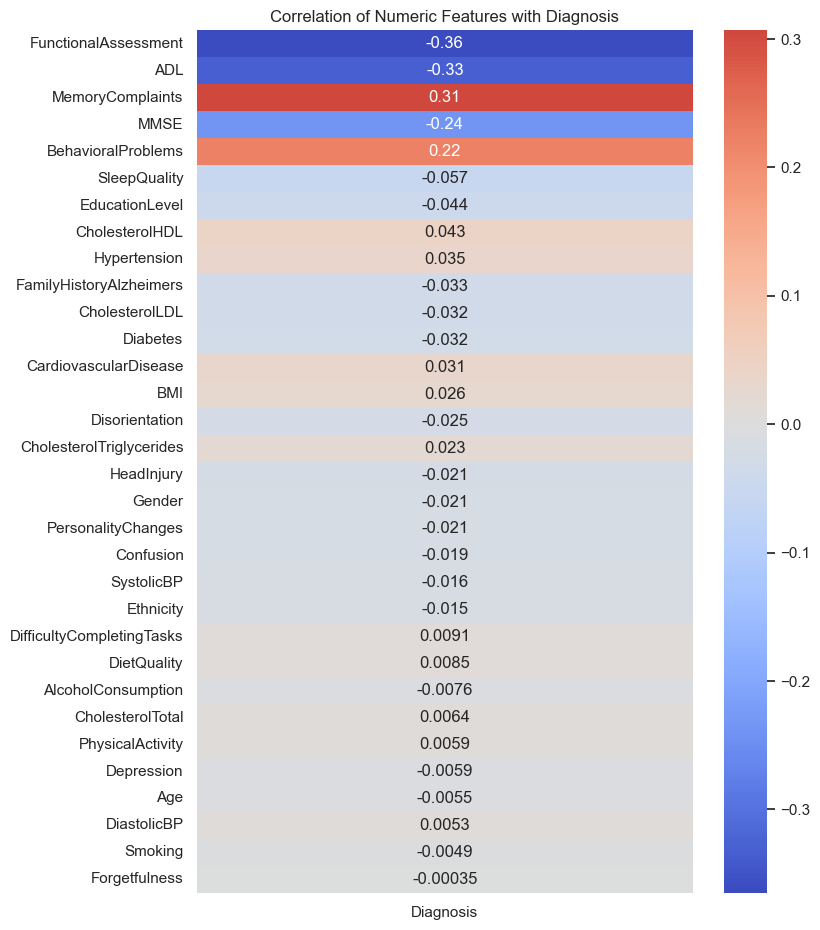

,correlation_with_diagnosis
FunctionalAssessment,-0.364898
ADL,-0.332346
MemoryComplaints,0.306742
MMSE,-0.237126
BehavioralProblems,0.224350
SleepQuality,-0.056548
EducationLevel,-0.043966
CholesterolHDL,0.042584
Hypertension,0.035080
FamilyHistoryAlzheimers,-0.032900


In [9]:
corr_df = df[numeric_cols + [target_col]].corr(numeric_only=True)
corr_with_target = corr_df[target_col].drop(target_col).sort_values(key=lambda s: s.abs(), ascending=False)

plt.figure(figsize=(8, max(6, len(corr_with_target)*0.35)))
sns.heatmap(corr_with_target.to_frame(), annot=True, cmap="coolwarm", center=0)
plt.title("Correlation of Numeric Features with Diagnosis")
plt.show()

display(corr_with_target.to_frame("correlation_with_diagnosis"))

## 9. Modeling helper functions

1. **Full model**: includes everything except ID-like columns  
2. **Reduced model**: removes variables 

In [ ]:
def build_preprocessor(X):
    cat_cols = X.select_dtypes(include=["object", "category", "bool"]).columns.tolist()
    num_cols = [c for c in X.columns if c not in cat_cols]

    numeric_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median"))
    ])

    categorical_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ])

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", numeric_transformer, num_cols),
            ("cat", categorical_transformer, cat_cols)
        ]
    )
    return preprocessor


def evaluate_model(X, y, model_name="Model", threshold=0.5, random_state=42):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=random_state, stratify=y
    )

    preprocessor = build_preprocessor(X)

    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestClassifier(
            n_estimators=300,
            random_state=random_state,
            class_weight="balanced",
            oob_score=True,
            n_jobs=-1
        ))
    ])

    pipeline.fit(X_train, y_train)
    y_proba = pipeline.predict_proba(X_test)[:, 1]
    y_pred = (y_proba >= threshold).astype(int)

    results = {
        "model_name": model_name,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "f1": f1_score(y_test, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_test, y_proba)
    }

    # Extract OOB score
    rf_model = pipeline.named_steps["model"]
    oob = rf_model.oob_score_
    results["oob_score"] = oob

    print(f"===== {model_name} =====")
    print("Metrics:")
    for k, v in results.items():
        if k != "model_name":
            print(f"{k}: {v:.3f}")

    print("\nClassification report:")
    print(classification_report(y_test, y_pred, zero_division=0))

    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap="Blues")
    plt.title(f"Confusion Matrix - {model_name}")
    plt.show()

    fpr, tpr, _ = roc_curve(y_test, y_proba)
    pr, rc, _ = precision_recall_curve(y_test, y_proba)
    pr_auc = auc(rc, pr)

    plt.figure(figsize=(6,4))
    plt.plot(fpr, tpr, label=f"AUC = {results['roc_auc']:.3f}")
    plt.plot([0,1], [0,1], linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve - {model_name}")
    plt.legend()
    plt.show()

    plt.figure(figsize=(6,4))
    plt.plot(rc, pr, label=f"PR AUC = {pr_auc:.3f}")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"Precision-Recall Curve - {model_name}")
    plt.legend()
    plt.show()

    return pipeline, X_train, X_test, y_train, y_test, y_proba, y_pred, results

## 10. Full model

===== Full Random Forest =====
Metrics:
accuracy: 0.933
precision: 0.942
recall: 0.862
f1: 0.900
roc_auc: 0.943
oob_score: 0.933

Classification report:
              precision    recall  f1-score   support

           0       0.93      0.97      0.95       278
           1       0.94      0.86      0.90       152

    accuracy                           0.93       430
   macro avg       0.94      0.92      0.92       430
weighted avg       0.93      0.93      0.93       430



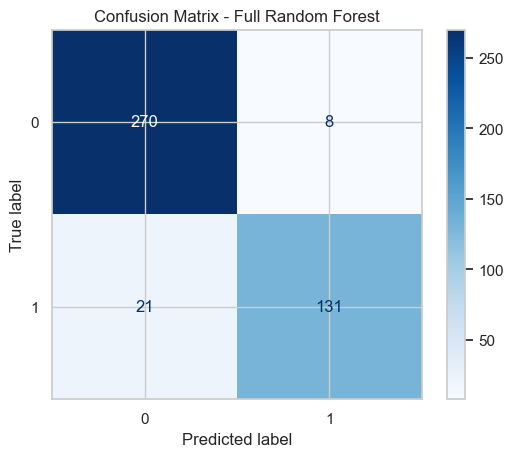

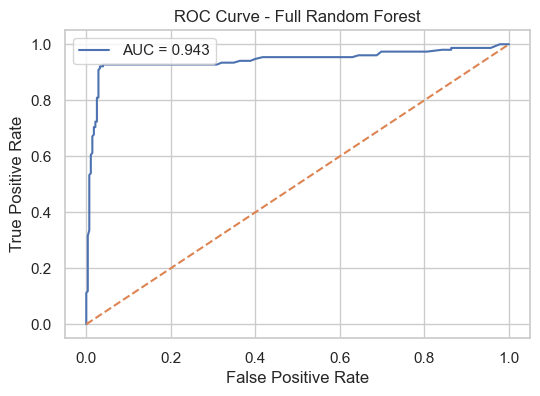

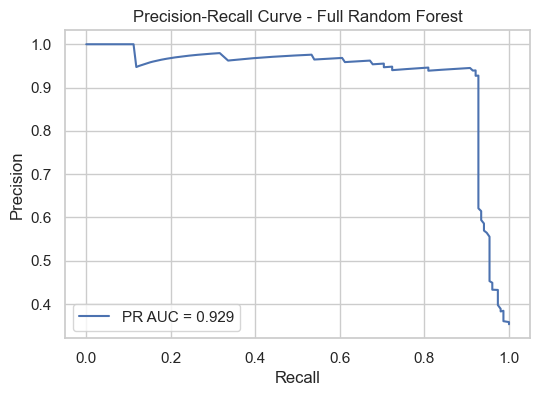

In [11]:
X_full = df.drop(columns=[target_col])
y = df[target_col]

full_model, X_train_full, X_test_full, y_train_full, y_test_full, y_proba_full, y_pred_full, full_results = evaluate_model(
    X_full, y, model_name="Full Random Forest"
)

## 11. Permutation importance for full model

,feature,importance_mean,importance_std
23,FunctionalAssessment,0.165349,0.013737
26,ADL,0.138605,0.017899
22,MMSE,0.129070,0.016420
24,MemoryComplaints,0.081860,0.010494
25,BehavioralProblems,0.064419,0.007992
5,Smoking,0.001628,0.001066
9,SleepQuality,0.001163,0.003330
11,CardiovascularDisease,0.000698,0.001066
28,Disorientation,0.000698,0.001066
14,HeadInjury,0.000698,0.001066


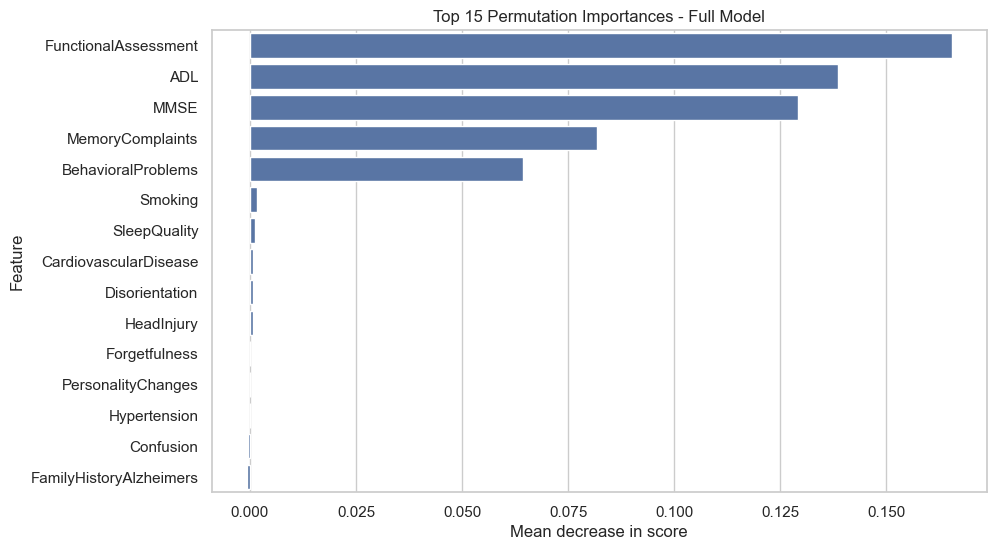

In [12]:
perm_full = permutation_importance(
    full_model, X_test_full, y_test_full,
    n_repeats=10, random_state=42, n_jobs=-1
)

importance_full = pd.DataFrame({
    "feature": X_test_full.columns,
    "importance_mean": perm_full.importances_mean,
    "importance_std": perm_full.importances_std
}).sort_values("importance_mean", ascending=False)

display(importance_full.head(20))

plt.figure(figsize=(10,6))
sns.barplot(data=importance_full.head(15), x="importance_mean", y="feature")
plt.title("Top 15 Permutation Importances - Full Model")
plt.xlabel("Mean decrease in score")
plt.ylabel("Feature")
plt.show()

## 12. Reduced model without near-diagnostic cognitive/functional variables

Removed from reduced model: ['MMSE', 'FunctionalAssessment', 'ADL', 'MemoryComplaints', 'BehavioralProblems', 'Confusion', 'Disorientation', 'PersonalityChanges', 'DifficultyCompletingTasks', 'Forgetfulness']
===== Reduced Random Forest (risk factors only) =====
Metrics:
accuracy: 0.640
precision: 0.286
recall: 0.013
f1: 0.025
roc_auc: 0.469
oob_score: 0.649

Classification report:
              precision    recall  f1-score   support

           0       0.65      0.98      0.78       278
           1       0.29      0.01      0.03       152

    accuracy                           0.64       430
   macro avg       0.47      0.50      0.40       430
weighted avg       0.52      0.64      0.51       430



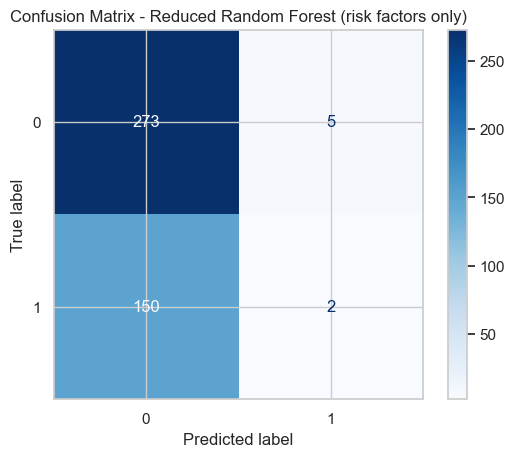

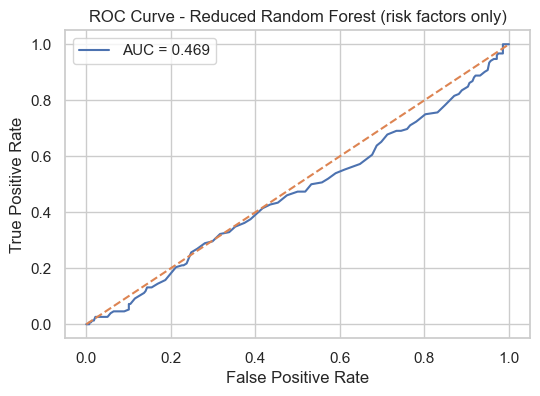

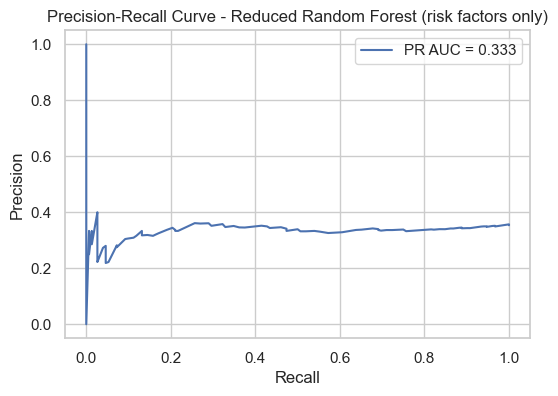

In [13]:
near_diagnostic_cols = [
    c for c in [
        "MMSE",
        "FunctionalAssessment",
        "ADL",
        "MemoryComplaints",
        "BehavioralProblems",
        "Confusion",
        "Disorientation",
        "PersonalityChanges",
        "DifficultyCompletingTasks",
        "Forgetfulness",
    ] if c in df.columns
]

print("Removed from reduced model:", near_diagnostic_cols)

X_reduced = df.drop(columns=[target_col] + near_diagnostic_cols)

reduced_model, X_train_red, X_test_red, y_train_red, y_test_red, y_proba_red, y_pred_red, reduced_results = evaluate_model(
    X_reduced, y, model_name="Reduced Random Forest (risk factors only)"
)

## 13. Permutation importance for reduced model

,feature,importance_mean,importance_std
12,Diabetes,7.674419e-03,0.002951
19,CholesterolLDL,3.720930e-03,0.002590
6,AlcoholConsumption,3.255814e-03,0.004557
21,CholesterolTriglycerides,3.023256e-03,0.004035
20,CholesterolHDL,3.023256e-03,0.006744
15,Hypertension,2.558140e-03,0.002428
11,CardiovascularDisease,2.093023e-03,0.001628
8,DietQuality,1.860465e-03,0.003721
1,Gender,1.627907e-03,0.002337
2,Ethnicity,1.627907e-03,0.001816


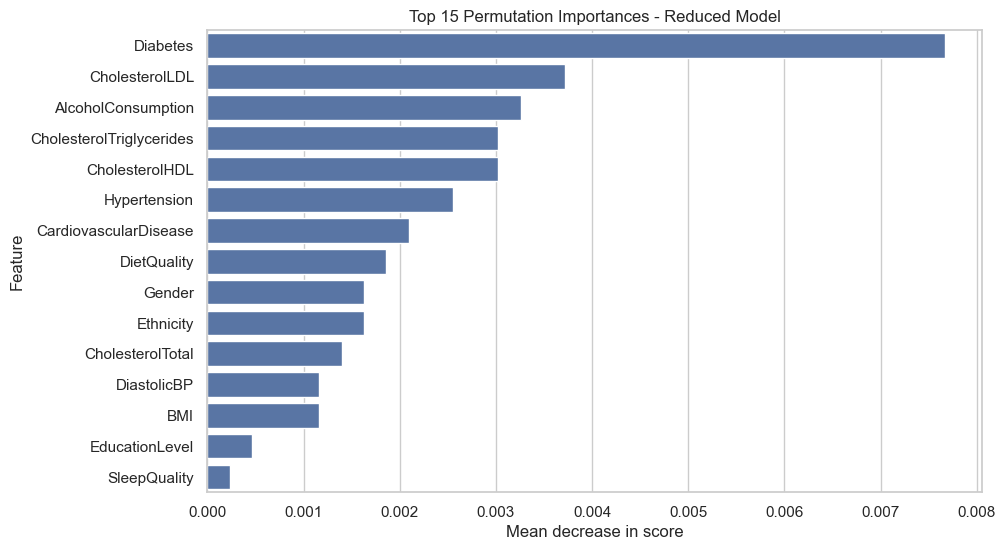

In [14]:
perm_red = permutation_importance(
    reduced_model, X_test_red, y_test_red,
    n_repeats=10, random_state=42, n_jobs=-1
)

importance_red = pd.DataFrame({
    "feature": X_test_red.columns,
    "importance_mean": perm_red.importances_mean,
    "importance_std": perm_red.importances_std
}).sort_values("importance_mean", ascending=False)

display(importance_red.head(20))

plt.figure(figsize=(10,6))
sns.barplot(data=importance_red.head(15), x="importance_mean", y="feature")
plt.title("Top 15 Permutation Importances - Reduced Model")
plt.xlabel("Mean decrease in score")
plt.ylabel("Feature")
plt.show()

## 14. Compare the two model settings

In [15]:
comparison = pd.DataFrame([full_results, reduced_results]).set_index("model_name").round(3)
display(comparison)

,accuracy,precision,recall,f1,roc_auc,oob_score
model_name,,,,,,
Full Random Forest,0.933,0.942,0.862,0.900,0.943,0.933
Reduced Random Forest (risk factors only),0.640,0.286,0.013,0.025,0.469,0.649


## 15. Threshold tuning for the reduced model

In medical problems, recall for the positive class can matter more than accuracy.  
This section tests several thresholds to see whether we can catch more positive cases.

,threshold,accuracy,precision,recall,f1
0,0.20,0.360465,0.355294,0.993421,0.523397
1,0.25,0.353488,0.343284,0.907895,0.498195
2,0.30,0.402326,0.336449,0.710526,0.456660
3,0.35,0.490698,0.341232,0.473684,0.396694
4,0.40,0.572093,0.333333,0.210526,0.258065
5,0.45,0.606977,0.282051,0.072368,0.115183
6,0.50,0.639535,0.285714,0.013158,0.025157
7,0.55,0.641860,0.000000,0.000000,0.000000
8,0.60,0.646512,0.000000,0.000000,0.000000
9,0.65,0.646512,0.000000,0.000000,0.000000


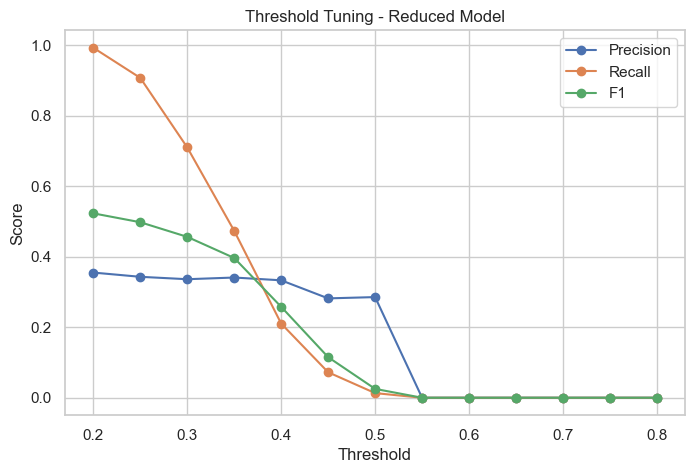

In [16]:
thresholds = np.arange(0.2, 0.8, 0.05)
rows = []

for t in thresholds:
    y_pred_t = (y_proba_red >= t).astype(int)
    rows.append({
        "threshold": round(float(t), 2),
        "accuracy": accuracy_score(y_test_red, y_pred_t),
        "precision": precision_score(y_test_red, y_pred_t, zero_division=0),
        "recall": recall_score(y_test_red, y_pred_t, zero_division=0),
        "f1": f1_score(y_test_red, y_pred_t, zero_division=0)
    })

threshold_df = pd.DataFrame(rows)
display(threshold_df)

plt.figure(figsize=(8,5))
plt.plot(threshold_df["threshold"], threshold_df["precision"], marker="o", label="Precision")
plt.plot(threshold_df["threshold"], threshold_df["recall"], marker="o", label="Recall")
plt.plot(threshold_df["threshold"], threshold_df["f1"], marker="o", label="F1")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Threshold Tuning - Reduced Model")
plt.legend()
plt.show()

## 16. Cross-validated AUC

A single train/test split can be noisy.  
This section gives a more stable view of model quality.

In [17]:
def cv_auc_score(X, y, random_state=42):
    preprocessor = build_preprocessor(X)
    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestClassifier(
            n_estimators=300,
            random_state=random_state,
            class_weight="balanced",
            n_jobs=-1
        ))
    ])
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=random_state)
    auc_scores = cross_val_score(pipeline, X, y, cv=cv, scoring="roc_auc", n_jobs=-1)
    return auc_scores

full_cv_auc = cv_auc_score(X_full, y)
reduced_cv_auc = cv_auc_score(X_reduced, y)

print("Full model CV ROC-AUC:", np.round(full_cv_auc, 3), "| mean =", round(full_cv_auc.mean(), 3))
print("Reduced model CV ROC-AUC:", np.round(reduced_cv_auc, 3), "| mean =", round(reduced_cv_auc.mean(), 3))

Full model CV ROC-AUC: [0.956 0.956 0.936 0.956 0.953] | mean = 0.951
Reduced model CV ROC-AUC: [0.524 0.543 0.481 0.498 0.482] | mean = 0.506


## 17. Age subgroup analysis

This is useful because Alzheimer’s risk may behave differently in older subgroups.  
You can change the age cutoff if needed.

Subset size for Age >= 75: (1091, 33)
===== Reduced Model in Age >= 75 =====
Metrics:
accuracy: 0.635
precision: 0.333
recall: 0.026
f1: 0.048
roc_auc: 0.499
oob_score: 0.624

Classification report:
              precision    recall  f1-score   support

           0       0.64      0.97      0.77       141
           1       0.33      0.03      0.05        78

    accuracy                           0.63       219
   macro avg       0.49      0.50      0.41       219
weighted avg       0.53      0.63      0.52       219



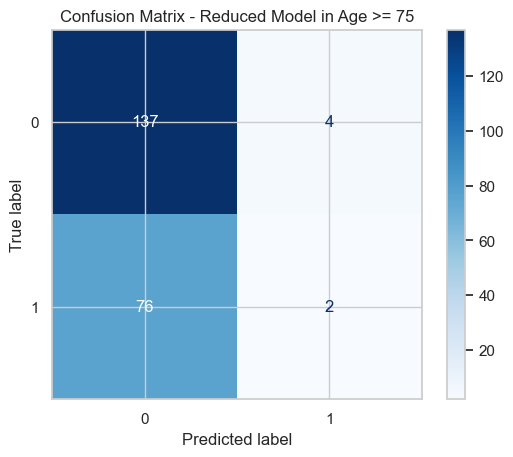

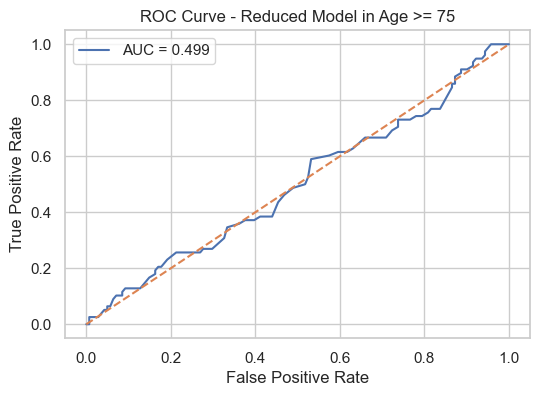

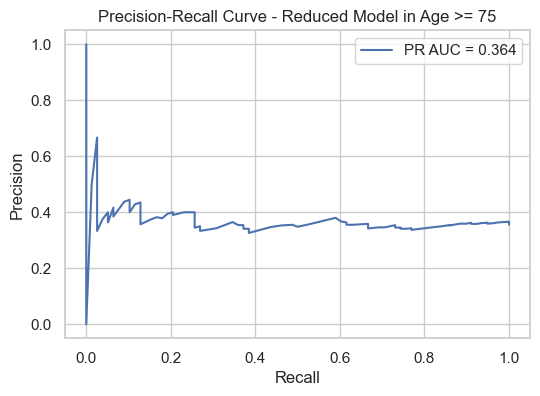

{'model_name': 'Reduced Model in Age >= 75', 'accuracy': 0.634703196347032, 'precision': 0.3333333333333333, 'recall': 0.02564102564102564, 'f1': 0.047619047619047616, 'roc_auc': 0.4990452809601746, 'oob_score': 0.6238532110091743}


In [18]:
if "Age" in df.columns:
    age_cutoff = 75
    older_df = df[df["Age"] >= age_cutoff].copy()

    print(f"Subset size for Age >= {age_cutoff}:", older_df.shape)
    if older_df.shape[0] > 100 and older_df[target_col].nunique() == 2:
        X_old = older_df.drop(columns=[target_col] + near_diagnostic_cols, errors="ignore")
        y_old = older_df[target_col]

        old_model, X_train_old, X_test_old, y_train_old, y_test_old, y_proba_old, y_pred_old, old_results = evaluate_model(
            X_old, y_old, model_name=f"Reduced Model in Age >= {age_cutoff}"
        )
        print(old_results)
    else:
        print("Not enough rows or not enough class variation for this subgroup.")
else:
    print("Age column not found.")

## 18. Quick binary-feature prevalence comparison

This is helpful for variables like:
- Smoking
- Diabetes
- Depression
- Hypertension
- FamilyHistoryAlzheimers

It shows the proportion of positive cases within each diagnosis group.

Diagnosis,0,1
Gender,0.514039,0.492105
MemoryComplaints,0.115911,0.376316
Forgetfulness,0.301656,0.301316
Smoking,0.290137,0.285526
BehavioralProblems,0.096472,0.267105
FamilyHistoryAlzheimers,0.262779,0.232895
Depression,0.202304,0.197368
Confusion,0.210943,0.194737
Hypertension,0.139669,0.165789
DifficultyCompletingTasks,0.156228,0.163158


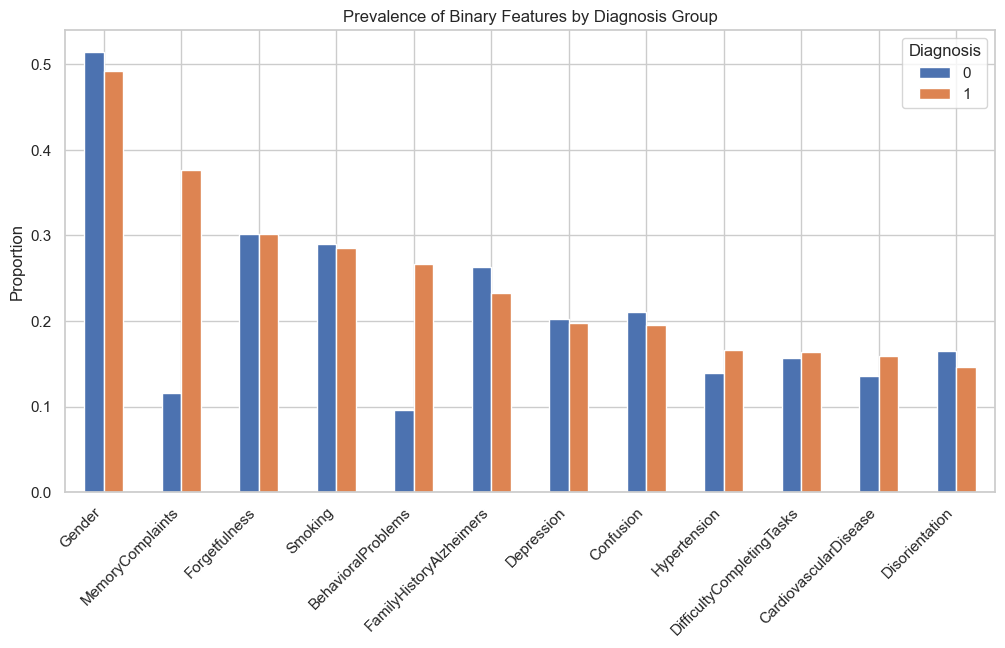

In [19]:
binary_like_cols = []
for col in df.columns:
    if col != target_col and df[col].dropna().nunique() <= 2:
        binary_like_cols.append(col)

binary_like_cols = [c for c in binary_like_cols if c not in categorical_cols or df[c].dropna().isin([0,1]).all()]

if binary_like_cols:
    prevalence = df.groupby(target_col)[binary_like_cols].mean().T.sort_values(by=1 if 1 in df[target_col].unique() else df[target_col].unique()[-1], ascending=False)
    display(prevalence)

    plot_cols = prevalence.head(12).index.tolist()
    prevalence.loc[plot_cols].plot(kind="bar", figsize=(12,6))
    plt.title("Prevalence of Binary Features by Diagnosis Group")
    plt.ylabel("Proportion")
    plt.xticks(rotation=45, ha="right")
    plt.show()
else:
    print("No binary-like columns detected.")